# Faithful copy of pinellolab's `predict_enhancer_activity.ipynb` (KLF1)

This matches the upstream EPInformer notebook **cell-for-cell**: predict K562 enhancer
activity in 256-bp windows across the CRISPRi-validated KLF1 enhancer, then run in-silico
saturation mutagenesis (ISM) to expose the TF motif — using the **published fold-8 encoder**,
the **hg19** genome, and the Fulco-2019 CRISPRi-FlowFISH table, exactly as upstream.

Everything is verbatim from `3_predict_enhancer_activity.ipynb` / `scripts/utils.py` except three
unavoidable environment adaptations, flagged inline:
1. `tangermeme.ism` was renamed `tangermeme.saturation_mutagenesis` in tangermeme ≥1.x (same function).
2. the hg19 FASTA path points at our symlink `data/reference/hg19/hg19.fa` instead of `../hg19.fa`.
3. `torch.load(..., weights_only=False)` for torch ≥2.6; repo-relative checkpoint / xlsx paths.

The upstream `predict_enhancer_activity` returns **raw** activity (`2**pred - 0.1`), scans
`window_size=512+256` (12 windows, start-anchored `[i, i+256]`), and picks the enhancer as
`KLF1_validated_enhancers.iloc[1]` — all preserved here.


In [1]:
%matplotlib inline
from EPInformer.models import enhancer_predictor_256bp
import torch
# --- adaptation 1: tangermeme.ism -> tangermeme.saturation_mutagenesis (renamed, identical fn) ---
try:
    from tangermeme.ism import saturation_mutagenesis
except ModuleNotFoundError:
    from tangermeme.saturation_mutagenesis import saturation_mutagenesis
from tangermeme.plot import plot_logo

from matplotlib import pyplot as plt
import seaborn as sns; sns.set_style('white')
import pandas as pd
import numpy as np
from scipy import stats
import os, sys
sys.path.insert(0, '.')

### Upstream helper functions (verbatim from `scripts/utils.py`)
`one_hot_encode` and `predict_enhancer_activity` are copied verbatim; only the hard-coded
`hg19_fasta_path = '../hg19.fa'` download block is replaced by our local hg19 symlink.

In [2]:
from preprocessing.fasta import FastaStringExtractor   # same extractor as upstream (kipoiseq.Interval, N-pad)
HG19_FASTA = 'data/reference/hg19/hg19.fa'                # adaptation 2: our hg19 symlink

def one_hot_encode(sequence):
    return kipoiseq.transforms.functional.one_hot_dna(sequence).astype(np.float32)

def predict_enhancer_activity(enhancer_model, chrom, position, window_size=1024, stride=128,
                              device='cpu', fasta_path=HG19_FASTA):
    import kipoiseq
    hg19_fasta_extractor = FastaStringExtractor(fasta_path)
    center = position
    print('The extened enhancer region: {}:{}-{}'.format(chrom, center - window_size, center + window_size))
    info_list = []
    for i in range(center - window_size, center + window_size, stride):
        target_interval = kipoiseq.Interval(chrom, i, i + 256)
        seq = hg19_fasta_extractor.extract(target_interval)
        seq_code = one_hot_encode(seq)
        seq_code = seq_code[np.newaxis, np.newaxis, :]
        seq_code_tensor = torch.Tensor(seq_code).to(device)
        enhancer_model.eval()
        with torch.no_grad():
            pred = enhancer_model(seq_code_tensor).cpu().detach().numpy()[0]
            pred_ori = 2 ** pred - 0.1
        info_list.append([chrom, i, i + 256, seq, center, pred_ori])
    return pd.DataFrame(info_list, columns=['chrom', 'start', 'end', 'seq', 'enhancer_mid', 'pred'])

import kipoiseq

## Predict enhancer activity and discover TF motifs at CRISPRi-validated enhancer of KLF1 in K562

In [3]:
# Load CRISPRi-FlowFISH data  (Fulco et al. 2019, Nat Genet 41588_2019_538, Supplementary Table 6a)
flowfish_df = pd.read_excel('data/CRISPRi-FlowFISH_Fulco2019/41588_2019_538_MOESM3_ESM.xlsx',
                            sheet_name='Supplementary Table 6a', skiprows=[0])
flowfish_df['mid'] = flowfish_df['start'] + (flowfish_df['end'] - flowfish_df['start']) / 2
flowfish_df['Distance_withDirect'] = flowfish_df['mid'] - flowfish_df['Gene TSS']
flowfish_df['Distance'] = np.abs(flowfish_df['Distance_withDirect'])
flowfish_100kb_df = flowfish_df[flowfish_df['Distance'] < 100_000]
# CRISPRi-validated (significant, repressive) enhancer regions for KLF1
KLF1_validated_enhancers = flowfish_100kb_df[(flowfish_100kb_df['Gene'] == 'KLF1') &
                                             (flowfish_100kb_df['Significant']) &
                                             (flowfish_100kb_df['Fraction change in gene expr'] < 0)].reset_index()
KLF1_validated_enhancers[['chr', 'start', 'end', 'mid', 'Gene TSS', 'Distance_withDirect', 'Fraction change in gene expr']]

,chr,start,end,mid,Gene TSS,Distance_withDirect,Fraction change in gene expr
0,chr19,12958325,12958825,12958575.0,12998017,-39442.0,-0.057784
1,chr19,12977965,12978745,12978355.0,12998017,-19662.0,-0.026087
2,chr19,12992085,12992645,12992365.0,12998017,-5652.0,-0.161863
3,chr19,12999705,13000205,12999955.0,12998017,1938.0,-0.169294
4,chr19,13001505,13002192,13001848.5,12998017,3831.5,-0.124012


In [4]:
enhancer_locus = KLF1_validated_enhancers.iloc[1]['mid']
enhancer_chrom = KLF1_validated_enhancers.iloc[1]['chr']
# Load enhancer activity predictor (the PUBLISHED pinellolab fold-8 encoder, copied into this repo)
device = 'cpu'
net = enhancer_predictor_256bp().to(device)
pt_model_name = 'K562_seq2activityLog2_leaveChrOut_combinedRS_2bins_bs64_H3K27ac_adamW_erisxdl_r0'
checkpoint = torch.load("trained_models/pretrained_enhancer_encoder/fold_8_best_" + pt_model_name + "_checkpoint.pt",
                        map_location=torch.device('cpu'), weights_only=False)   # adaptation 3: weights_only=False
net.load_state_dict(checkpoint['model_state_dict'])
# Predict enhancer activity
pred_info = predict_enhancer_activity(net, enhancer_chrom, int(enhancer_locus), window_size=512 + 256, stride=128, device='cpu')
print('enhancer:', enhancer_chrom, int(enhancer_locus), '(hg19)  ->  peak raw activity =', round(pred_info['pred'].max(), 2))

The extened enhancer region: chr19:12977587-12979123


enhancer: chr19 12978355 (hg19)  ->  peak raw activity = 2.64


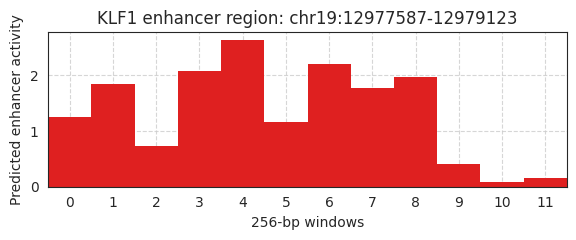

In [5]:
plt.figure(figsize=(6, 2.5))
sns.barplot(x=pred_info.index, y='pred', data=pred_info, color='red', width=1, linewidth=0)
plt.grid(linestyle='--', alpha=0.8)
plt.ylabel('Predicted enhancer activity')
plt.xlabel('256-bp windows')
plt.title('KLF1 enhancer region: chr19:12977587-12979123')
plt.tight_layout()
plt.show()

In [6]:
# calculate ISM score for the top 256-bp window
top_activity_256bp = pred_info.sort_values(by='pred', ascending=False).iloc[0]  # top 256-bp window
seq_ohe = one_hot_encode(top_activity_256bp.seq)
seq_tensor = torch.from_numpy(seq_ohe).unsqueeze(0).permute(0, 2, 1)
seq_ISM = saturation_mutagenesis(net, seq_tensor, device='cpu')

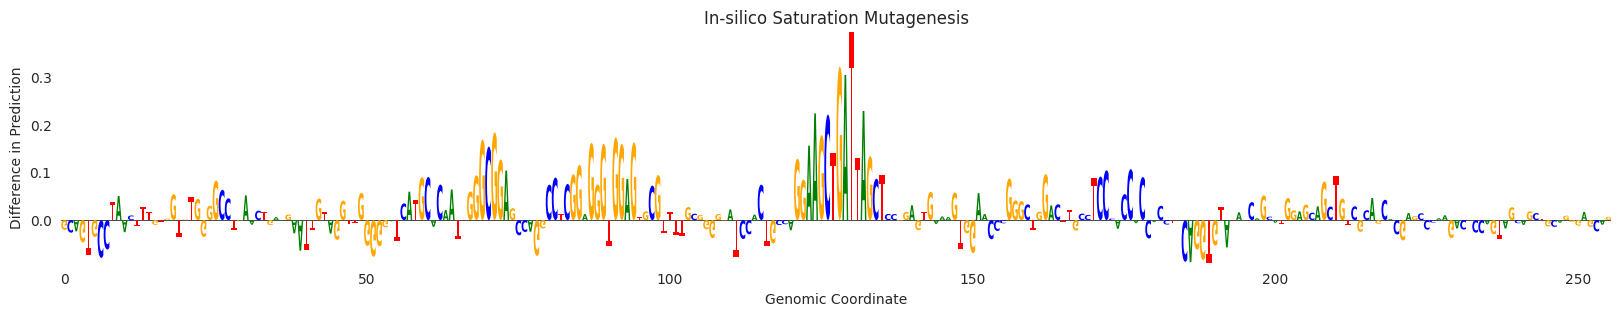

In [7]:
plt.figure(figsize=(20, 3))
ax = plt.subplot(111)
plot_logo(seq_ISM[0], ax=ax)
plt.xlabel("Genomic Coordinate")
plt.ylabel("Difference in Prediction")
plt.title("In-silico Saturation Mutagenesis")
plt.show()